In [1]:
# CELL 1
# Load the RSHQ quarterly worker numbers file and inspect the Minerals Surface sheet.
# This sheet contains reported headcounts for all Queensland open cut/exploration
# mineral mines — the same category as Ravenswood Gold (surface mineral mine).
# We confirm the layout before building the extraction loop in CELL 2.

import pandas as pd
import os

file_path = os.path.join('..', 'data', 'raw', 'quarterly-worker-numbers_31december2025.xlsx')

# Load Minerals Surface sheet, no header — we handle it manually
df_raw = pd.read_excel(file_path, sheet_name='Minerals Surface', header=None)

print(f"Sheet dimensions: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print()
print("Row 0:", df_raw.iloc[0, :6].tolist())
print("Row 1:", df_raw.iloc[1, :6].tolist())
print("Row 2:", df_raw.iloc[2, :6].tolist())
print("Row 3:", df_raw.iloc[3, :6].tolist())
print("Row 4:", df_raw.iloc[4, :6].tolist())

Sheet dimensions: 172 rows x 144 columns

Row 0: [np.float64(nan), 'Queensland Mineral Surface/Exploration Mines*', nan, np.float64(nan), 'Queensland Mineral Surface/Exploration Mines*', nan]
Row 1: [np.float64(nan), 'Reported number of workers as at 31 March 2014', nan, np.float64(nan), 'Reported number of workers as at 30 June 2014', nan]
Row 2: [np.float64(nan), 'Mine', 'No. of Workers', np.float64(nan), 'Mine', 'No. of Workers']
Row 3: [np.float64(nan), 'Bajool- Cheetham & Port Alma Mine', 48, np.float64(nan), 'AARD Metals Limited', 2]
Row 4: [np.float64(nan), 'Biggenden Mine', 8, np.float64(nan), 'Aeon Metals Exploration', 4]


c:\Users\ericm\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [3]:
# CELL 2 (CORRECTED)
# Same as CELL 2 but with a typo correction dictionary applied before date parsing.
# The source data contains "Sepetmber" (misspelled) in at least one quarter label —
# a real-world data quality issue common in manually maintained government spreadsheets.

records = []

total_cols = df_raw.shape[1]

for col_start in range(1, total_cols, 3):
    if col_start + 1 >= total_cols:
        break

    quarter_label = df_raw.iloc[1, col_start]
    if pd.isna(quarter_label):
        continue

    block = df_raw.iloc[3:, [col_start, col_start + 1]].copy()
    block.columns = ['mine', 'workers']

    block = block[block['mine'].notna()]
    block = block[block['mine'].astype(str).str.strip() != '']
    block = block[~block['mine'].astype(str).str.contains('Total', case=False, na=False)]

    block['workers'] = pd.to_numeric(block['workers'], errors='coerce')
    total_workers = block['workers'].sum()

    date_str = str(quarter_label).replace('Reported number of workers as at ', '').strip()

    records.append({
        'quarter_label': date_str,
        'total_surface_mineral_workers': int(total_workers)
    })

df_workers = pd.DataFrame(records)

# Typo correction dictionary — fix known misspellings in source data
typo_corrections = {
    'Sepetmber': 'September',
    'Feburary': 'February',
    'Janruary': 'January',
}
for typo, correct in typo_corrections.items():
    df_workers['quarter_label'] = df_workers['quarter_label'].str.replace(
        typo, correct, regex=False)

# Convert to datetime
df_workers['quarter_date'] = pd.to_datetime(
    df_workers['quarter_label'], format='%d %B %Y')

# Sort by date
df_workers = df_workers.sort_values('quarter_date').reset_index(drop=True)

print(f"Total quarters extracted: {len(df_workers)}")
print()
print(df_workers.head(10).to_string(index=False))

Total quarters extracted: 48

    quarter_label  total_surface_mineral_workers quarter_date
    31 March 2014                           6308   2014-03-31
     30 June 2014                           7386   2014-06-30
30 September 2014                           5967   2014-09-30
 31 December 2014                           5502   2014-12-31
    31 March 2015                           5208   2015-03-31
     30 June 2015                           5550   2015-06-30
30 September 2015                           4902   2015-09-30
 31 December 2015                           5052   2015-12-31
    31 March 2016                           4374   2016-03-31
     30 June 2016                           4638   2016-06-30


In [4]:
# CELL 3
# Add a financial year label to each quarter for joining with the production master
# table later in the database. Queensland financial years run July to June,
# so quarters ending September, December and March belong to the same FY
# as the following June quarter.
# We also compute annual average workers per financial year for trend analysis.

def assign_financial_year(date):
    if date.month >= 7:
        return f"{date.year}-{str(date.year + 1)[2:]}"
    else:
        return f"{date.year - 1}-{str(date.year)[2:]}"

df_workers['financial_year'] = df_workers['quarter_date'].apply(assign_financial_year)

# Annual average workers per financial year
df_workers_annual = df_workers.groupby('financial_year').agg(
    avg_workers=('total_surface_mineral_workers', 'mean'),
    max_workers=('total_surface_mineral_workers', 'max'),
    min_workers=('total_surface_mineral_workers', 'min'),
    quarters_reported=('total_surface_mineral_workers', 'count')
).reset_index()

df_workers_annual['avg_workers'] = df_workers_annual['avg_workers'].round(0).astype(int)
df_workers_annual['max_workers'] = df_workers_annual['max_workers'].astype(int)
df_workers_annual['min_workers'] = df_workers_annual['min_workers'].astype(int)

print("Quarterly data sample (last 8 quarters):")
print(df_workers.tail(8).to_string(index=False))
print()
print("Annual summary:")
print(df_workers_annual.to_string(index=False))

Quarterly data sample (last 8 quarters):
    quarter_label  total_surface_mineral_workers quarter_date financial_year
    31 March 2024                           5958   2024-03-31        2023-24
     30 June 2024                           6423   2024-06-30        2023-24
30 September 2024                           6773   2024-09-30        2024-25
 31 December 2024                           6675   2024-12-31        2024-25
    31 March 2025                           5815   2025-03-31        2024-25
     30 June 2025                           6298   2025-06-30        2024-25
30 September 2025                           6759   2025-09-30        2025-26
 31 December 2025                           6694   2025-12-31        2025-26

Annual summary:
financial_year  avg_workers  max_workers  min_workers  quarters_reported
       2013-14         6847         7386         6308                  2
       2014-15         5557         5967         5208                  4
       2015-16         4742   

C:\Users\ericm\AppData\Local\Temp\ipykernel_36840\4027114543.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_workers_annual['financial_year'], rotation=45, ha='right')


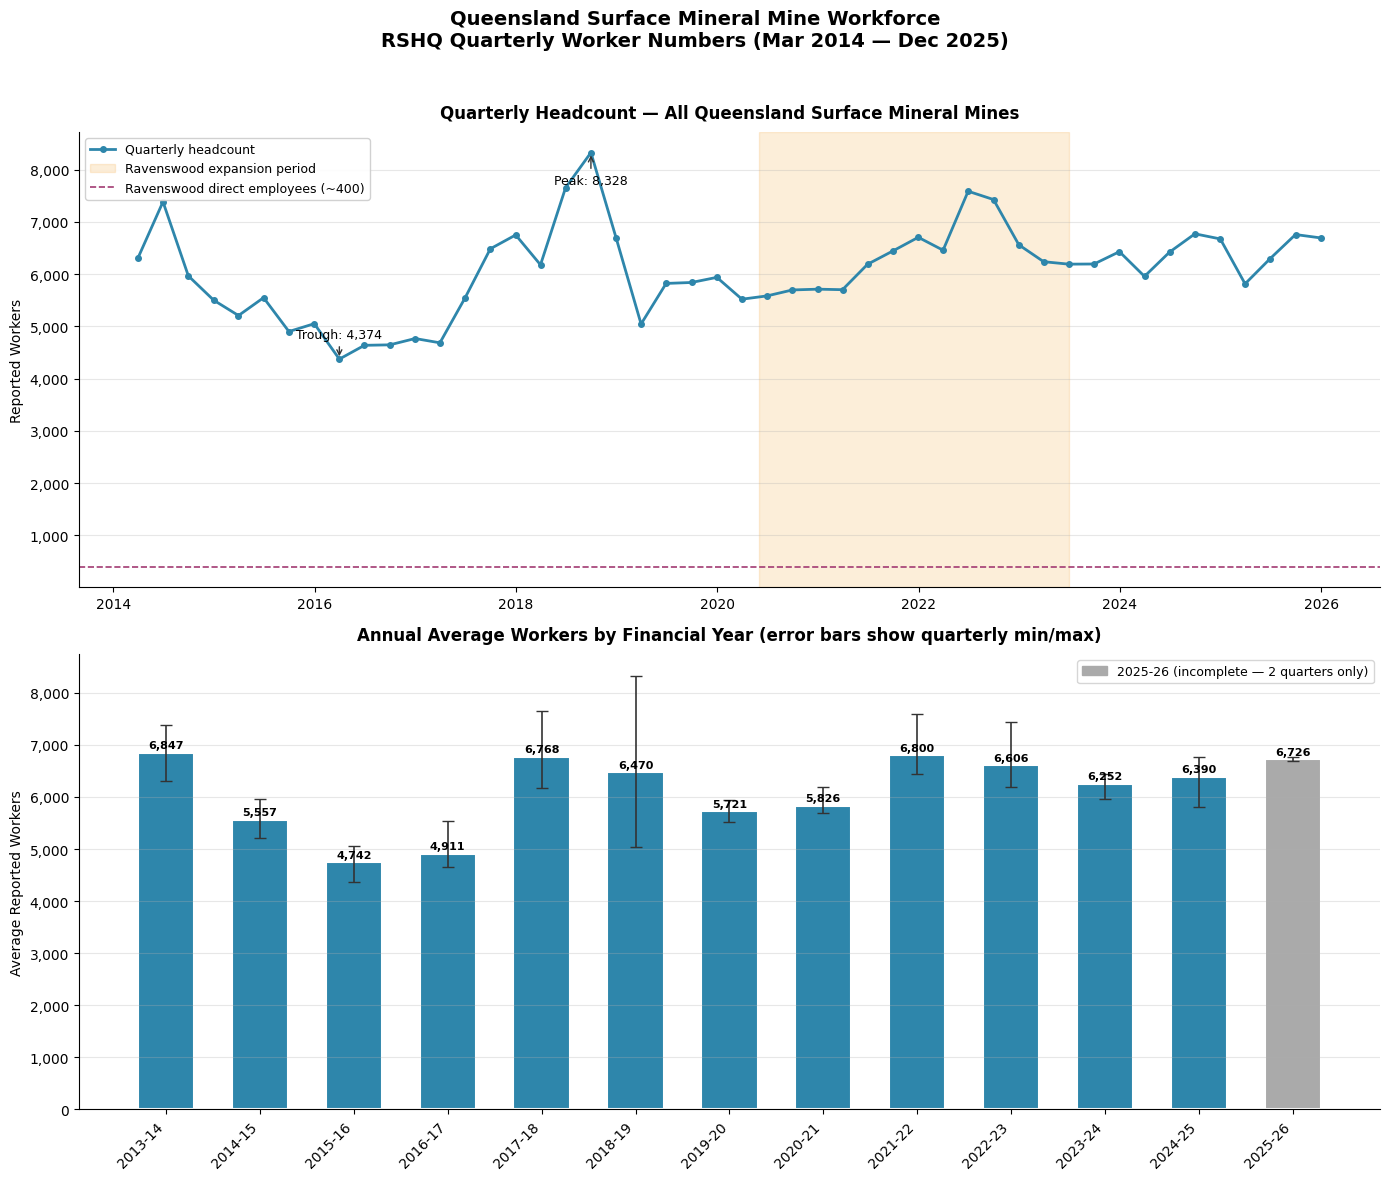

Chart saved to output/02_labour_workforce_trend.png


In [5]:
# CELL 4
# Visualise Queensland surface mineral mine workforce trends across two charts:
#   1. Quarterly headcount time series (shows seasonality and volatility)
#   2. Annual average workers by financial year (shows structural trend)
# The 2025-26 financial year is flagged as incomplete (only 2 quarters reported).

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Queensland Surface Mineral Mine Workforce\nRSHQ Quarterly Worker Numbers (Mar 2014 — Dec 2025)',
             fontsize=14, fontweight='bold', y=0.98)

# --- Chart 1: Quarterly time series ---
ax1 = axes[0]
ax1.plot(df_workers['quarter_date'],
         df_workers['total_surface_mineral_workers'],
         color='#2E86AB', linewidth=2, marker='o', markersize=4, label='Quarterly headcount')

# Shade Ravenswood expansion period
ax1.axvspan(pd.Timestamp('2020-06-01'), pd.Timestamp('2023-06-30'),
            alpha=0.15, color='#F18F01', label='Ravenswood expansion period')

# Reference line for Ravenswood's ~400 direct employees
ax1.axhline(y=400, color='#A23B72', linestyle='--', linewidth=1.2,
            label='Ravenswood direct employees (~400)')

ax1.set_title('Quarterly Headcount — All Queensland Surface Mineral Mines',
              fontweight='bold', pad=10)
ax1.set_ylabel('Reported Workers')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Annotate trough and peak
min_idx = df_workers['total_surface_mineral_workers'].idxmin()
max_idx = df_workers['total_surface_mineral_workers'].idxmax()
ax1.annotate(f"Trough: {df_workers.loc[min_idx, 'total_surface_mineral_workers']:,}",
             xy=(df_workers.loc[min_idx, 'quarter_date'],
                 df_workers.loc[min_idx, 'total_surface_mineral_workers']),
             xytext=(df_workers.loc[min_idx, 'quarter_date'],
                     df_workers.loc[min_idx, 'total_surface_mineral_workers'] + 400),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center')
ax1.annotate(f"Peak: {df_workers.loc[max_idx, 'total_surface_mineral_workers']:,}",
             xy=(df_workers.loc[max_idx, 'quarter_date'],
                 df_workers.loc[max_idx, 'total_surface_mineral_workers']),
             xytext=(df_workers.loc[max_idx, 'quarter_date'],
                     df_workers.loc[max_idx, 'total_surface_mineral_workers'] - 600),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center')

# --- Chart 2: Annual average bar chart ---
ax2 = axes[1]

# Flag incomplete year
colours = ['#AAAAAA' if fy == '2025-26' else '#2E86AB'
           for fy in df_workers_annual['financial_year']]

bars = ax2.bar(df_workers_annual['financial_year'],
               df_workers_annual['avg_workers'],
               color=colours, edgecolor='white', linewidth=1.5, width=0.6)

# Error bars showing min/max range
ax2.errorbar(df_workers_annual['financial_year'],
             df_workers_annual['avg_workers'],
             yerr=[df_workers_annual['avg_workers'] - df_workers_annual['min_workers'],
                   df_workers_annual['max_workers'] - df_workers_annual['avg_workers']],
             fmt='none', color='#333333', capsize=4, linewidth=1.2)

ax2.set_title('Annual Average Workers by Financial Year (error bars show quarterly min/max)',
              fontweight='bold', pad=10)
ax2.set_ylabel('Average Reported Workers')
ax2.set_xticklabels(df_workers_annual['financial_year'], rotation=45, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Label bars
for bar, val in zip(bars, df_workers_annual['avg_workers']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

# Legend for incomplete year
incomplete_patch = mpatches.Patch(color='#AAAAAA', label='2025-26 (incomplete — 2 quarters only)')
ax2.legend(handles=[incomplete_patch], loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

output_dir = os.path.join('..', 'output')
plt.savefig(os.path.join(output_dir, '02_labour_workforce_trend.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output/02_labour_workforce_trend.png")

In [6]:
# CELL 5
# Link the labour data to the production master table built in Notebook 01.
# We calculate two derived metrics:
#   1. Ore tonnes processed per worker — a proxy for labour productivity
#   2. Workers per million tonnes (WpMt) — standard mining industry benchmark
# This directly answers the job requirement: "Productivity per employee"
# and links the Labour pillar to the Production pillar in the database.
# Note: we use annual average workers aligned to the same financial years
# available in the production master (2021-22 to 2023-24).

# Load production master built in Notebook 01
production_path = os.path.join('..', 'data', 'processed', 'production', 'gold_production_qld.csv')
production_master = pd.read_csv(production_path)

# Merge annual worker averages with production master on financial year
labour_production = production_master.merge(
    df_workers_annual[['financial_year', 'avg_workers', 'max_workers', 'min_workers']],
    on='financial_year',
    how='left'
)

# Calculate productivity metrics
labour_production['tonnes_per_worker'] = (
    labour_production['ore_throughput_tonnes'] / labour_production['avg_workers']
).round(0)

labour_production['workers_per_mtpa'] = (
    labour_production['avg_workers'] / (labour_production['ore_throughput_tonnes'] / 1e6)
).round(1)

labour_production['gold_oz_per_worker'] = (
    labour_production['gold_recovered_oz'] / labour_production['avg_workers']
).round(2)

# Select and display key columns
display_cols = ['financial_year', 'ore_throughput_tonnes', 'avg_workers',
                'tonnes_per_worker', 'workers_per_mtpa', 'gold_oz_per_worker',
                'recovery_rate_pct']

print(labour_production[display_cols].to_string(index=False))

financial_year  ore_throughput_tonnes  avg_workers  tonnes_per_worker  workers_per_mtpa  gold_oz_per_worker  recovery_rate_pct
       2021-22              8951016.0         6800             1316.0             759.7               74.48              96.40
       2022-23             14642594.0         6606             2217.0             451.1               92.00              98.14
       2023-24             13515493.0         6252             2162.0             462.6              106.40              53.87


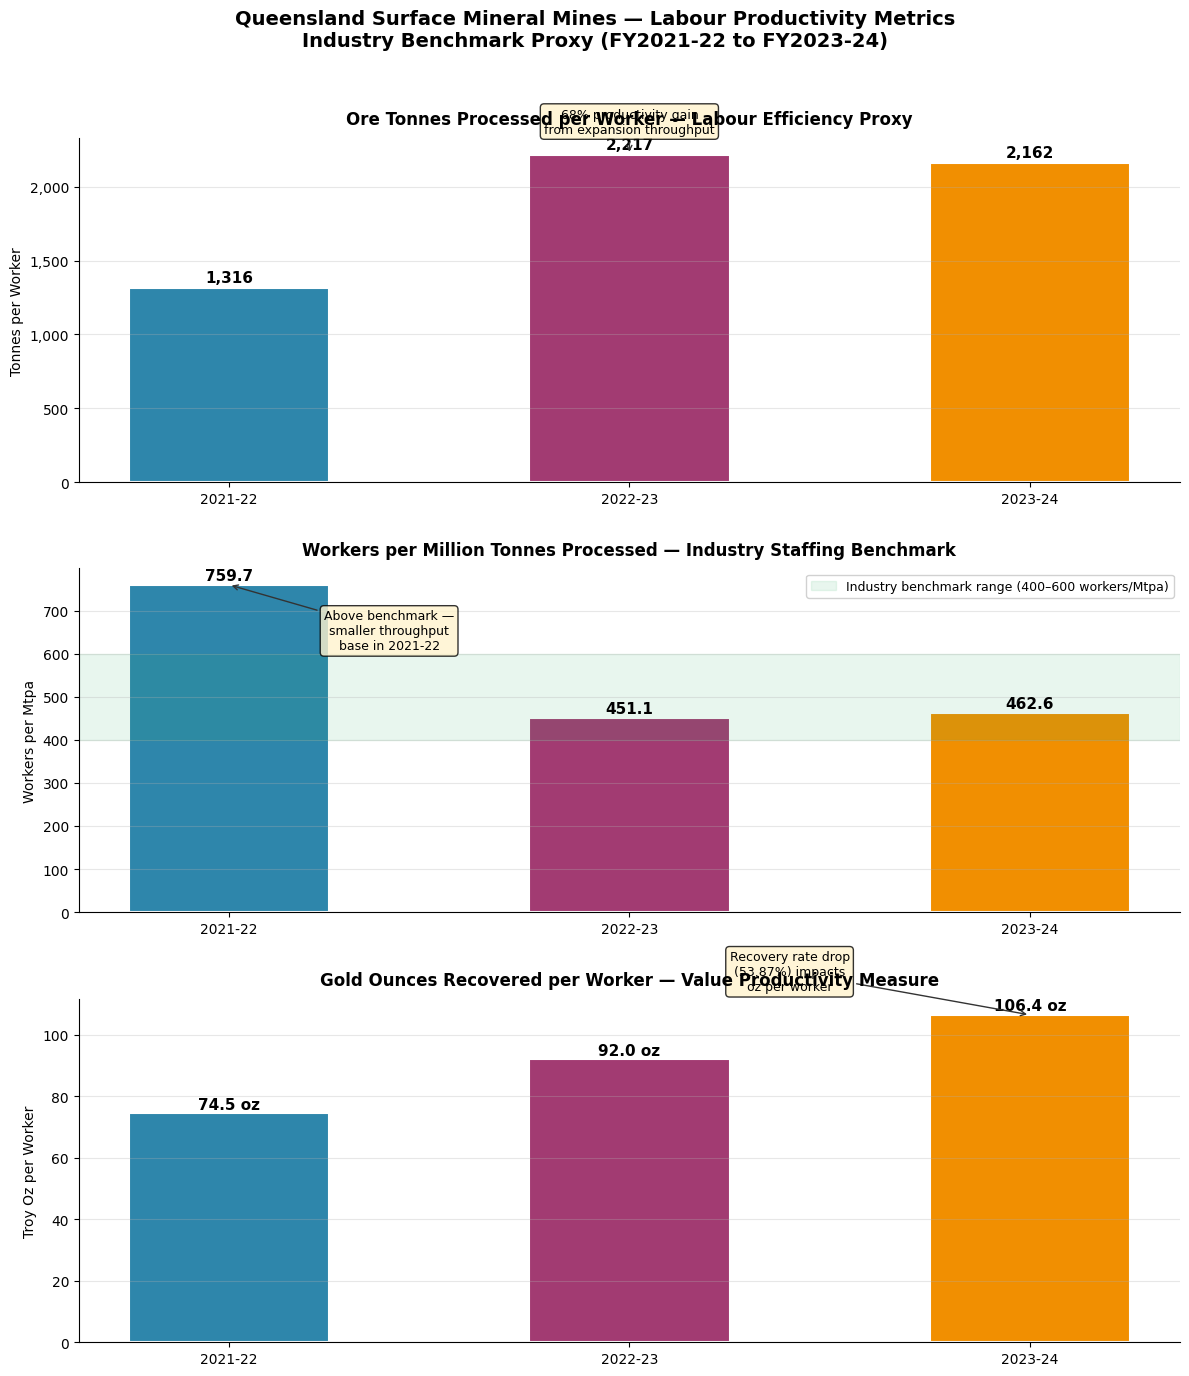

Chart saved to output/03_labour_productivity.png
Data saved to data/processed/labour/qld_surface_mineral_workers_quarterly.csv
Data saved to data/processed/labour/labour_production_linked.csv


In [7]:
# CELL 6
# Visualise the three labour productivity metrics across financial years:
#   1. Tonnes processed per worker — overall labour efficiency
#   2. Workers per million tonnes — industry standard staffing benchmark
#   3. Gold ounces recovered per worker — value-based productivity measure
# Then save the linked labour-production table to the processed data folder.
# These are Queensland-wide benchmarks — Ravenswood site-specific estimates
# will be modelled in Notebook 04 using publicly stated operational figures.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Queensland Surface Mineral Mines — Labour Productivity Metrics\n'
             'Industry Benchmark Proxy (FY2021-22 to FY2023-24)',
             fontsize=14, fontweight='bold', y=0.98)

years = labour_production['financial_year']
x = range(len(years))
colours = ['#2E86AB', '#A23B72', '#F18F01']

# --- Chart 1: Tonnes per worker ---
ax1 = axes[0]
bars1 = ax1.bar(x, labour_production['tonnes_per_worker'],
                color=colours, width=0.5, edgecolor='white', linewidth=1.5)
ax1.set_title('Ore Tonnes Processed per Worker — Labour Efficiency Proxy',
              fontweight='bold', pad=10)
ax1.set_ylabel('Tonnes per Worker')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars1, labour_production['tonnes_per_worker']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'{int(val):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Annotate productivity jump
ax1.annotate('68% productivity gain\nfrom expansion throughput',
             xy=(1, labour_production['tonnes_per_worker'].iloc[1]),
             xytext=(1, labour_production['tonnes_per_worker'].iloc[1] + 150),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

# --- Chart 2: Workers per million tonnes ---
ax2 = axes[1]
bars2 = ax2.bar(x, labour_production['workers_per_mtpa'],
                color=colours, width=0.5, edgecolor='white', linewidth=1.5)

# Industry benchmark range shading
ax2.axhspan(400, 600, alpha=0.1, color='#27AE60',
            label='Industry benchmark range (400–600 workers/Mtpa)')
ax2.set_title('Workers per Million Tonnes Processed — Industry Staffing Benchmark',
              fontweight='bold', pad=10)
ax2.set_ylabel('Workers per Mtpa')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
for bar, val in zip(bars2, labour_production['workers_per_mtpa']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{val:.1f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Annotate 2021-22 being above benchmark
ax2.annotate('Above benchmark —\nsmaller throughput\nbase in 2021-22',
             xy=(0, labour_production['workers_per_mtpa'].iloc[0]),
             xytext=(0.4, labour_production['workers_per_mtpa'].iloc[0] - 150),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

# --- Chart 3: Gold oz per worker ---
ax3 = axes[2]
bars3 = ax3.bar(x, labour_production['gold_oz_per_worker'],
                color=colours, width=0.5, edgecolor='white', linewidth=1.5)
ax3.set_title('Gold Ounces Recovered per Worker — Value Productivity Measure',
              fontweight='bold', pad=10)
ax3.set_ylabel('Troy Oz per Worker')
ax3.set_xticks(x)
ax3.set_xticklabels(years)
for bar, val in zip(bars3, labour_production['gold_oz_per_worker']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f} oz',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Annotate 2023-24 drop linked to recovery rate
ax3.annotate('Recovery rate drop\n(53.87%) impacts\noz per worker',
             xy=(2, labour_production['gold_oz_per_worker'].iloc[2]),
             xytext=(1.4, labour_production['gold_oz_per_worker'].iloc[2] + 8),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save chart
output_dir = os.path.join('..', 'output')
plt.savefig(os.path.join(output_dir, '03_labour_productivity.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output/03_labour_productivity.png")

# Save to processed folder
processed_dir = os.path.join('..', 'data', 'processed', 'labour')
os.makedirs(processed_dir, exist_ok=True)

# Save quarterly workers
df_workers.to_csv(
    os.path.join(processed_dir, 'qld_surface_mineral_workers_quarterly.csv'), index=False)

# Save labour-production linked table
labour_production.to_csv(
    os.path.join(processed_dir, 'labour_production_linked.csv'), index=False)

print("Data saved to data/processed/labour/qld_surface_mineral_workers_quarterly.csv")
print("Data saved to data/processed/labour/labour_production_linked.csv")